# GKBA vs exact (Krylov) — spin density comparison

Compares the GKBA (pos-rep, static and dynamic lead GF) against the exact
single-particle propagation $C(t+\delta t) = e^{-iH\delta t}\,C(t)\,e^{iH\delta t}$
for two setups:

- **1 lead** (left lead only)
- **2 leads** (left + right)

Same parameters and initial conditions in all cases: quench from the decoupled
equilibrium state at $t=0$, then propagate with precessing spins.

In [1]:
using LinearAlgebra, DifferentialEquations
using PyPlot

import GKBA: build_hs, build_heα_posrep, build_hseα_posrep,
             init_gkba_posrep, init_egkba_posrep,
             eom_gkba_posrep!, eom_egkba_posrep!,
             compute_observables!, unpack!,
             PrecSpin, update!, fermi, K_BOLTZMAN
import GKBA: σ_x, σ_y, σ_z

In [2]:
rc("text", usetex=true)
rc("font", family="serif")
rc("text.latex", preamble=raw"\usepackage{amsmath}")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)

## Common parameters

In [26]:
nx, ny  = 2, 1
ns      = nx * ny
nk      = 60       # lead sites (pos-rep)
nσ      = 2
γ       = 1.0
γso     = 0.0
γc      = 1.0
j_sd    = 0.1
Temp    = 300.0
β       = 1.0 / (K_BOLTZMAN * Temp)

t_0     = 0.0
dt      = 0.1
t_end   = 100.0
ts      = collect(t_0 + dt : dt : t_end)

# Precessing spins
theta_1 = 20.0
phi_1   = 0.0
period  = 5.0

Ne = nk * nσ   # lead DOF
Ns = ns * nσ   # system DOF

4

## Helper functions

In [27]:
# Precessing spin initializer
function make_spins(nx; theta=theta_1, phi=phi_1, T=period)
    [PrecSpin(i; theta_zero=theta, phi_zero=phi, T=T) for i in 1:nx]
end

function vm_at(t; nx=nx)
    ps = make_spins(nx)
    vm = zeros(Float64, nx, 3)
    for p in ps; update!(p, t); vm[p.i, :] .= p.s; end
    vm
end

# Build time-dependent htot (layout: lead_L | system | [lead_R])
function build_htot(t, nα)
    vm   = vm_at(t)
    hs   = build_hs(vm, nx, ny, γ, γso, j_sd)
    heα  = build_heα_posrep(zeros(nα), γ, nk, nσ, nα)
    hseα = build_hseα_posrep(ns, γc, nk, nσ, nα)
    dim  = nα * Ne + Ns
    H    = zeros(ComplexF64, dim, dim)
    # diagonal blocks
    for α in 1:nα
        r = (α-1)*Ne+1 : α*Ne
        H[r, r] = heα[:, :, α]
    end
    rS = nα*Ne+1 : nα*Ne+Ns
    H[rS, rS] = hs
    # coupling blocks
    for α in 1:nα
        r = (α-1)*Ne+1 : α*Ne
        H[rS, r] = hseα[:, :, α]
        H[r, rS] = hseα[:, :, α]'
    end
    return H, nα*Ne+1 : nα*Ne+Ns   # H and system index range rS
end

# Initial correlation matrix: decoupled equilibrium
function init_C(nα)
    vm0  = vm_at(0.0)
    hs0  = build_hs(vm0, nx, ny, γ, γso, j_sd)
    heα0 = build_heα_posrep(zeros(nα), γ, nk, nσ, nα)
    dim  = nα * Ne + Ns
    C    = zeros(ComplexF64, dim, dim)
    # system block
    εs, Us = eigen(hs0)
    C[nα*Ne+1:end, nα*Ne+1:end] = Us * Diagonal(fermi.(εs * β)) * Us'
    # lead blocks
    for α in 1:nα
        r = (α-1)*Ne+1 : α*Ne
        εe, Ue = eigen(heα0[:, :, α])
        C[r, r] = Ue * Diagonal(fermi.(εe * β)) * Ue'
    end
    return C
end

# One exact step: C ← exp(-iH dt) C exp(iH dt)
function exact_step!(C, H, dt)
    U  = exp(-1im * dt * H)
    C .= U * C * U'
end

# Observables from C
σs = [σ_x, σ_y, σ_z]
sblock(site, nα) = nα*Ne + (2site-1) : nα*Ne + 2site

function sden_from_C(C, nα)
    [real(tr(C[sblock(s, nα), sblock(s, nα)] * σs[x]))
     for s in 1:ns, x in 1:3]
end

function scurr_from_C(C, H, nα, site, α)
    # spin current from system site → lead α edge (coupling at k-modes 1,2)
    rL  = (α-1)*Ne+1 : (α-1)*Ne+2
    rSi = sblock(site, nα)
    [4π * imag(tr(H[rSi, rL] * C[rL, rSi] * σs[x])) for x in 1:3]
end

scurr_from_C (generic function with 1 method)

## Exact propagation

In [28]:
function run_exact(nα)
    C    = init_C(nα)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)     # spin current to lead 1
    t    = t_0
    for (n, tt) in enumerate(ts)
        H, rS = build_htot(t + 0.5dt, nα)   # midpoint rule
        exact_step!(C, H, dt)
        C .= 0.5 * (C + C')                 # enforce Hermiticity
        t  = tt
        H_now, _ = build_htot(tt, nα)
        sden[n, :, :] = sden_from_C(C, nα)
        sc[n, :]      = scurr_from_C(C, H_now, nα, 1, 1)
    end
    sden, sc
end

run_exact (generic function with 1 method)

## GKBA propagation (pos-rep, static and dynamic lead GF)

In [29]:
function run_gkba_posrep(nα)
    vm0      = vm_at(0.0)
    dv, ov   = init_gkba_posrep(; nx, ny, nk, γ, γso, γc, j_sd, Temp,
                                  vm_i1x=vm0, nα=nα,
                                  μ_α=zeros(nα), ϵ0α=zeros(nα))
    prob     = ODEProblem(eom_gkba_posrep!, dv.rkvec, (t_0, t_end), dv)
    integ    = init(prob, RK4(); dt=dt, save_everystep=false,
                   adaptive=false, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

function run_egkba_posrep(nα)
    vm0      = vm_at(0.0)
    dv, ov   = init_egkba_posrep(; nx, ny, nk, γ, γso, γc, j_sd, Temp,
                                   vm_i1x=vm0, nα=nα,
                                   μ_α=zeros(nα), ϵ0α=zeros(nα))
    prob     = ODEProblem(eom_egkba_posrep!, dv.rkvec, (t_0, t_end), dv)
    integ    = init(prob, RK4(); dt=dt, save_everystep=false,
                   adaptive=false, dense=false)
    sden = zeros(Float64, length(ts), ns, 3)
    sc   = zeros(Float64, length(ts), 3)
    ps   = make_spins(nx)
    for (n, tt) in enumerate(ts)
        step!(integ, dt, true)
        unpack!(dv, integ.u)
        compute_observables!(ov, dv)
        for p in ps; update!(p, tt); dv.vm_i1x[p.i, :] .= p.s; end
        dv.hs_ij = build_hs(dv.vm_i1x, nx, ny, γ, γso, j_sd)
        sden[n, :, :] = ov.sden_i1x
        sc[n, :]      = ov.scurr_xα[:, 1]
    end
    sden, sc
end

run_egkba_posrep (generic function with 1 method)

---
## Section 1: 1 lead

Left lead only (`nα = 1`).

In [30]:
println("Running exact (1 lead)...")
@time sd_ex1, sc_ex1 = run_exact(1)

println("Running GKBA pos-rep (1 lead)...")
@time sd_gk1, sc_gk1 = run_gkba_posrep(1)

println("Running eGKBA pos-rep (1 lead)...")
@time sd_eg1, sc_eg1 = run_egkba_posrep(1)

println("Done.")

Running exact (1 lead)...
 11.744019 seconds (2.45 M allocations: 38.950 GiB, 16.63% gc time, 2.92% compilation time)
Running GKBA pos-rep (1 lead)...
  2.537055 seconds (57.74 M allocations: 1.982 GiB, 9.41% gc time)
Running eGKBA pos-rep (1 lead)...
 29.188625 seconds (57.77 M allocations: 3.918 GiB, 1.59% gc time)
Done.


### Spin density — site 1, 1 lead

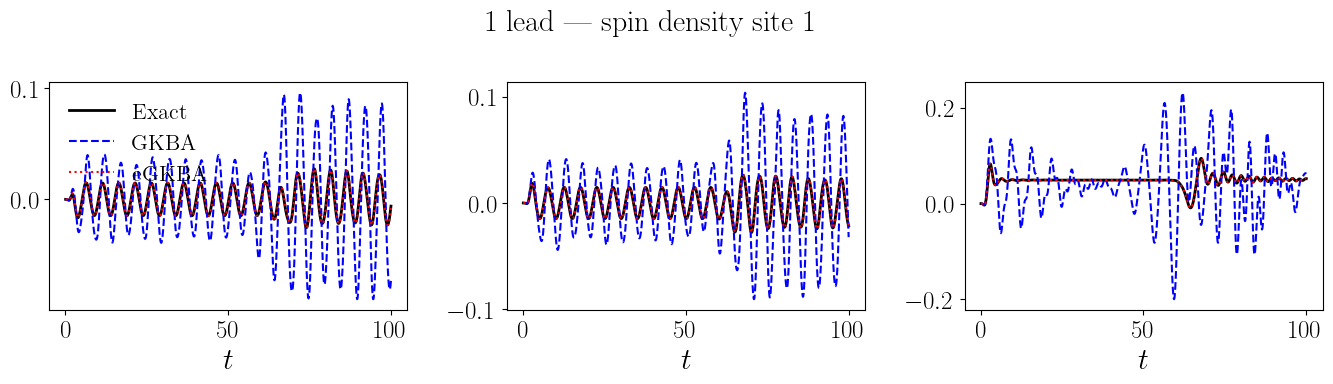

In [58]:
xlabels = ["x", "y", "z"]
site = 2

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sd_ex1[:, site, ix], "k-",  lw=2,   label="Exact")
    ax.plot(ts, sd_gk1[:, site, ix], "b--", lw=1.5, label="GKBA")
    ax.plot(ts, sd_eg1[:, site, ix], "r:",  lw=1.5, label="eGKBA")
    ax.set_xlabel(L"t")
    #ax.set_ylabel(L"\langle S^" * xlabels[ix] * L"_1 \rangle")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("1 lead — spin density site 1")
plt.tight_layout()

### Spin current to lead 1 — 1 lead

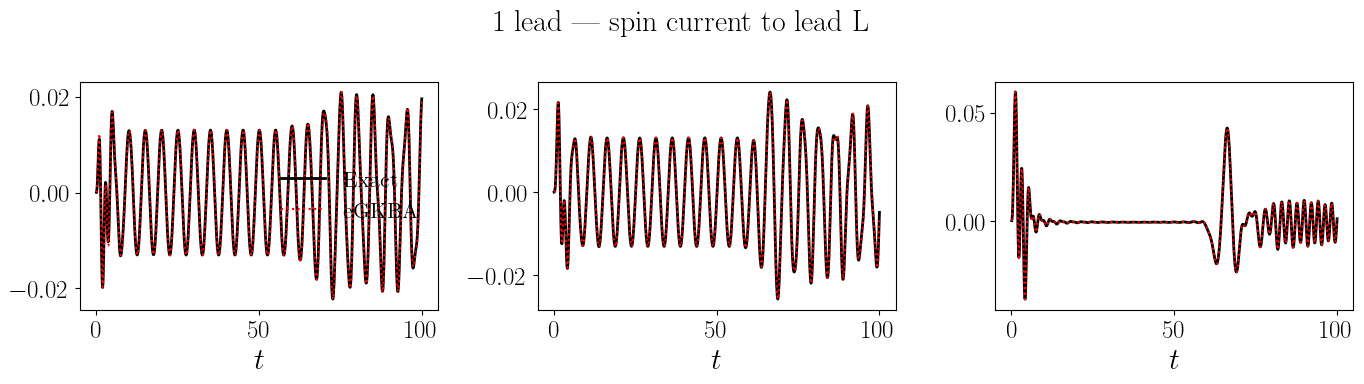

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sc_ex1[:, ix], "k-",  lw=2,   label="Exact")
    #ax.plot(ts, sc_gk1[:, ix], "b--", lw=1.5, label="GKBA")
    ax.plot(ts, sc_eg1[:, ix], "r:",  lw=1.5, label="eGKBA")
    ax.set_xlabel(L"t")
    #ax.set_ylabel(L"J^" * xlabels[ix] * L"_L")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("1 lead — spin current to lead L")
plt.tight_layout()

---
## Section 2: 2 leads

Left + right leads (`nα = 2`).

In [51]:
println("Running exact (2 leads)...")
@time sd_ex2, sc_ex2 = run_exact(2)

println("Running GKBA pos-rep (2 leads)...")
@time sd_gk2, sc_gk2 = run_gkba_posrep(2)

println("Running eGKBA pos-rep (2 leads)...")
@time sd_eg2, sc_eg2 = run_egkba_posrep(2)

println("Done.")

Running exact (2 leads)...
 19.307281 seconds (2.20 M allocations: 48.828 GiB, 13.59% gc time)
Running GKBA pos-rep (2 leads)...
  5.109691 seconds (115.34 M allocations: 3.937 GiB, 9.52% gc time)
Running eGKBA pos-rep (2 leads)...
 58.471364 seconds (115.37 M allocations: 7.807 GiB, 2.46% gc time)
Done.


### Spin density — site 1, 2 leads

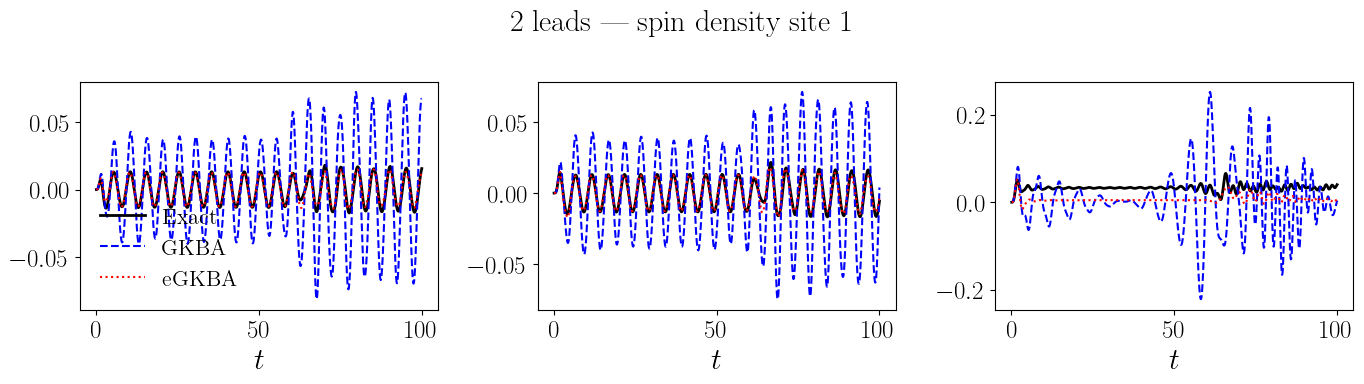

In [52]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sd_ex2[:, site, ix], "k-",  lw=2,   label="Exact")
    ax.plot(ts, sd_gk2[:, site, ix], "b--", lw=1.5, label="GKBA")
    ax.plot(ts, sd_eg2[:, site, ix], "r:",  lw=1.5, label="eGKBA")
    ax.set_xlabel(L"t")
    #ax.set_ylabel(L"\langle S^" * xlabels[ix] * L"_1 \rangle")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("2 leads — spin density site 1")
plt.tight_layout()

### Spin current to lead 1 — 2 leads

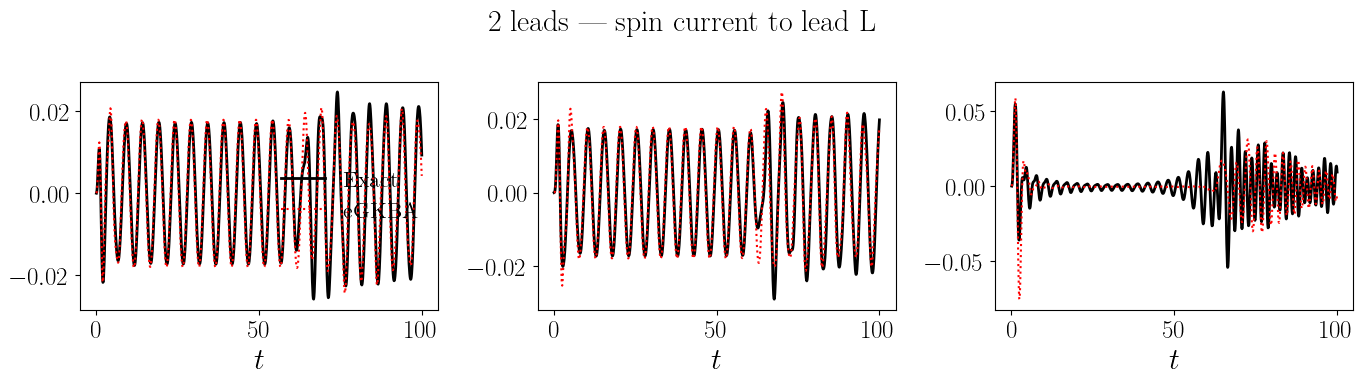

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=false)
for (ix, ax) in enumerate(axs)
    ax.plot(ts, sc_ex2[:, ix], "k-",  lw=2,   label="Exact")
    #ax.plot(ts, sc_gk2[:, ix], "b--", lw=1.5, label="GKBA")
    ax.plot(ts, sc_eg2[:, ix], "r:",  lw=1.5, label="eGKBA")
    ax.set_xlabel(L"t")
    #ax.set_ylabel(L"J^" * xlabels[ix] * L"_L")
    ix == 1 && ax.legend(frameon=false)
end
fig.suptitle("2 leads — spin current to lead L")
plt.tight_layout()